<a href="https://colab.research.google.com/github/avgvstinee/python-ml-essentials/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install and Libraries

In [3]:
!pip install torch torchvision matplotlib -q
!pip3 uninstall --yes torch torchaudio torchvision torchtext torchdata
!pip3 install torch torchaudio torchvision torchtext torchdata

Found existing installation: torch 2.9.0+cpu
Uninstalling torch-2.9.0+cpu:
  Successfully uninstalled torch-2.9.0+cpu
Found existing installation: torchaudio 2.9.0+cpu
Uninstalling torchaudio-2.9.0+cpu:
  Successfully uninstalled torchaudio-2.9.0+cpu
Found existing installation: torchvision 0.24.0+cpu
Uninstalling torchvision-0.24.0+cpu:
  Successfully uninstalled torchvision-0.24.0+cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 625.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 753.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 141.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 716.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Device Setup for Mac
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using MPS (Mac GPU)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA (NVIDIA GPU)")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU (Warning: This will be slow)")

Using CUDA (NVIDIA GPU)


# Data Augmentation

In [19]:

# Data Augmentation

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),(0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),(0.2675, 0.2565, 0.2761))
    ])


full_train_set = torchvision.datasets.CIFAR100(root='./data',
                                                   train=True,
                                                   download=True,
                                                   transform=transform_train
                                                   )
test_set = torchvision.datasets.CIFAR100(root='./data',
                                             train=False,
                                             download=True,
                                             transform=transform_test
                                             )

# Split 10% for validation
val_size = 5000
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(full_train_set,
                                          [train_size, val_size]
                                          )



train_loader = DataLoader(train_set, batch_size=128,
                          shuffle=True,
                          num_workers=2,
                          pin_memory=True)
val_loader   = DataLoader(val_set,
                          batch_size=128,
                          shuffle=False,
                          num_workers=2,
                          pin_memory=True)


# RESIDUAL +BLOCK



#
######   x ──► Conv3x3 ──► BN ──► ReLU ──► Conv3x3 ──► BN ──► (+) ──► ReLU
######   │                                                                              
######   └──────────────── downsampling ────────────────┘
#

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from typing import Any, Callable, List, Optional

def conv3x3(in_planes: int, out_planes: int, stride: int = 1,
            padding: int = 1) -> nn.Conv2d:
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=padding,
        bias=False
    )

class BasicBlock(nn.Module):
    expansion: int = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d

        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

# RESNET-18 ARCHITECTURE

#
###### Input (3,32,32)
######    │
######  Stem: Conv3x3-64, BN, ReLU          → (64,32,32)
######     │
######  Layer1: 2× BasicBlock(64→64,   s=1) → (64,32,32)
######   Layer2: 2× BasicBlock(64→128,  s=2) → (128,16,16)
######   Layer3: 2× BasicBlock(128→256, s=2) → (256,8,8)
######   Layer4: 2× BasicBlock(256→512, s=2) → (512,4,4)
######      │
######   GlobalAvgPool                        → (512,1,1)
######   Flatten                              → (512,)
######   Dropout(0.2)
######   Fully Connected 512→100                           → (100,)
#

In [5]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=100, dropout_p=0.2):
        super().__init__()
        # Stem — small 3×3 conv for CIFAR 32×32 (no maxpool)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.pool    = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc      = nn.Linear(512, num_classes)
        self._init_weights()

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        downsample = None
        if stride != 1 or in_ch != out_ch:
            downsample = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

        layers = [BasicBlock(in_ch, out_ch, stride=stride, downsample=downsample)]
        for _ in range(1, n_blocks):
            layers.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)                  # (B,64,32,32)
        x = self.layer1(x)                # (B,64,32,32)
        x = self.layer2(x)                # (B,128,16,16)
        x = self.layer3(x)                # (B,256,8,8)
        x = self.layer4(x)                # (B,512,4,4)
        x = self.pool(x).flatten(1)       # (B,512)
        x = self.dropout(x)
        return self.fc(x)                 # (B,100)


# Early Stopping

In [13]:
import copy

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float("inf")
        self.best_epoch = 0
        self.best_wts   = None
        self.stop       = False

    def step(self, val_loss, epoch, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_epoch = epoch
            self.best_wts   = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                model.load_state_dict(self.best_wts)   # restore best weights
                self.stop = True

# ONE EPOCH

In [14]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    loss_sum, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += logits.argmax(1).eq(labels).sum().item()
            total    += imgs.size(0)

    return loss_sum / total, 100.0 * correct / total

# Validate the Model

In [15]:
def validate(model, loader, criterion):
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return val_loss/len(loader), 100.*correct/total

# Hyperparameter Search

In [16]:
best_val_acc = 0
best_history = None

# Training the Model

In [20]:

for lr in [0.001, 0.01]:
    for wd in [1e-4, 5e-4]:
        print(f"Starting to train: LR={lr}, WD={wd}")
        # Note: Ensure MyResNet() has softmax REMOVED from forward()

        model = ResNet18().to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(model.parameters(),
                               lr=lr,
                               momentum=0.9,
                               weight_decay=wd,
                               nesterov=True
                               )

        scheduler = optim.lr_scheduler.StepLR(optimizer,
                                              step_size=30,
                                              gamma=0.1)


        history = {'training_loss': [], 'training_acc': [],
                   'validation_loss': [], 'validation_acc': []}

        early_stopping = EarlyStopping(patience=7, min_delta=1e-4)

        for epoch in range(100):
            training_loss, training_acc = run_epoch(model,
                                            train_loader,
                                            criterion,
                                            optimizer)
            validation_loss, validation_acc = validate(model, val_loader, criterion)
            scheduler.step()

            history['training_loss'].append(training_loss); history['training_acc'].append(training_acc)
            history['validation_loss'].append(validation_loss); history['validation_acc'].append(validation_acc)

            early_stopping.step(validation_loss, epoch, model)

            if validation_acc > best_val_acc:
                best_val_acc = validation_acc
                best_history = history.copy()
                torch.save(model.state_dict(), 'best_model.pth')

            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}: Train Loss {training_loss:.4f}, Train Acc {training_acc:.2f}%, Val Loss {validation_loss:.4f}, Val Acc {validation_acc:.2f}%, Dropout Gap: {(training_acc - validation_acc):.2f}%")

            if early_stopping.stop:
                print(f"Stopped early at epoch {epoch+1}")
                break



Starting to train: LR=0.001, WD=0.0001
Epoch 5: Train Loss 3.6714, Train Acc 13.96%, Val Loss 3.4731, Val Acc 17.58%, Dropout Gap: -3.62%
Epoch 10: Train Loss 3.2102, Train Acc 21.85%, Val Loss 3.0457, Val Acc 25.46%, Dropout Gap: -3.61%
Epoch 15: Train Loss 2.8841, Train Acc 27.52%, Val Loss 2.8805, Val Acc 28.12%, Dropout Gap: -0.60%
Epoch 20: Train Loss 2.6239, Train Acc 32.90%, Val Loss 2.5516, Val Acc 34.12%, Dropout Gap: -1.22%
Epoch 25: Train Loss 2.3878, Train Acc 37.80%, Val Loss 2.4033, Val Acc 37.68%, Dropout Gap: 0.12%
Epoch 30: Train Loss 2.1968, Train Acc 41.69%, Val Loss 2.2762, Val Acc 40.92%, Dropout Gap: 0.77%
Epoch 35: Train Loss 2.0508, Train Acc 44.95%, Val Loss 2.0937, Val Acc 44.40%, Dropout Gap: 0.55%
Epoch 40: Train Loss 2.0320, Train Acc 45.56%, Val Loss 2.1078, Val Acc 43.68%, Dropout Gap: 1.88%
Stopped early at epoch 42
Starting to train: LR=0.001, WD=0.0005
Epoch 5: Train Loss 3.6678, Train Acc 14.10%, Val Loss 3.4554, Val Acc 18.20%, Dropout Gap: -4.10%
Ep

# Model Visualization

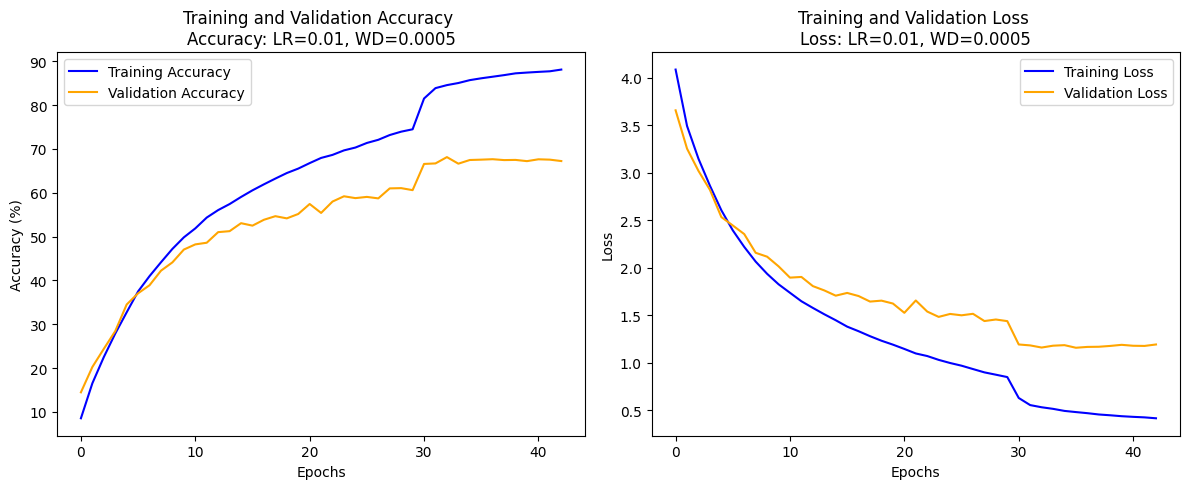

In [22]:
import matplotlib.pyplot as plt

# Using the data from your best run (LR=0.001, WD=0.0005)
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(best_history['training_acc'], label='Training Accuracy', color='blue')
plt.plot(best_history['validation_acc'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy \nAccuracy: LR=0.01, WD=0.0005')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(best_history['training_loss'], label='Training Loss', color='blue')
plt.plot(best_history['validation_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss \nLoss: LR=0.01, WD=0.0005')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:

for lr in [0.01]:
    for wd in [1e-3]:
        print(f"Starting to train: LR={lr}, WD={wd}")
        # Note: Ensure MyResNet() has softmax REMOVED from forward()

        model = ResNet18().to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(model.parameters(),
                               lr=lr,
                               momentum=0.9,
                               weight_decay=wd,
                               nesterov=True
                               )

        scheduler = optim.lr_scheduler.StepLR(optimizer,
                                              step_size=30,
                                              gamma=0.1)


        history = {'training_loss': [], 'training_acc': [],
                   'validation_loss': [], 'validation_acc': []}

        early_stopping = EarlyStopping(patience=7, min_delta=1e-4)

        for epoch in range(100):
            training_loss, training_acc = run_epoch(model,
                                            train_loader,
                                            criterion,
                                            optimizer)
            validation_loss, validation_acc = validate(model, val_loader, criterion)
            scheduler.step()

            history['training_loss'].append(training_loss); history['training_acc'].append(training_acc)
            history['validation_loss'].append(validation_loss); history['validation_acc'].append(validation_acc)

            early_stopping.step(validation_loss, epoch, model)

            if validation_acc > best_val_acc:
                best_val_acc = validation_acc
                best_history = history.copy()
                torch.save(model.state_dict(), 'best_model.pth')

            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}: Train Loss {training_loss:.4f}, Train Acc {training_acc:.2f}%, Val Loss {validation_loss:.4f}, Val Acc {validation_acc:.2f}%, Dropout Gap: {(training_acc - validation_acc):.2f}%")

            if early_stopping.stop:
                print(f"Stopped early at epoch {epoch+1}")
                break



Starting to train: LR=0.01, WD=0.001
Epoch 5: Train Loss 2.5559, Train Acc 33.89%, Val Loss 2.4432, Val Acc 36.02%, Dropout Gap: -2.13%
Epoch 10: Train Loss 1.8033, Train Acc 50.59%, Val Loss 1.9722, Val Acc 46.62%, Dropout Gap: 3.97%
Epoch 15: Train Loss 1.4380, Train Acc 59.47%, Val Loss 1.7492, Val Acc 52.24%, Dropout Gap: 7.23%
Epoch 20: Train Loss 1.1971, Train Acc 65.54%, Val Loss 1.6073, Val Acc 56.40%, Dropout Gap: 9.14%
Epoch 25: Train Loss 1.0324, Train Acc 69.94%, Val Loss 1.4951, Val Acc 58.70%, Dropout Gap: 11.24%
Epoch 30: Train Loss 0.8966, Train Acc 73.61%, Val Loss 1.5394, Val Acc 59.52%, Dropout Gap: 14.09%
Epoch 35: Train Loss 0.4840, Train Acc 86.48%, Val Loss 1.1255, Val Acc 68.30%, Dropout Gap: 18.18%
Epoch 40: Train Loss 0.4081, Train Acc 88.84%, Val Loss 1.1350, Val Acc 68.54%, Dropout Gap: 20.30%
Epoch 45: Train Loss 0.3558, Train Acc 90.43%, Val Loss 1.1331, Val Acc 68.92%, Dropout Gap: 21.51%
Stopped early at epoch 46


# VISUALIZATIONS

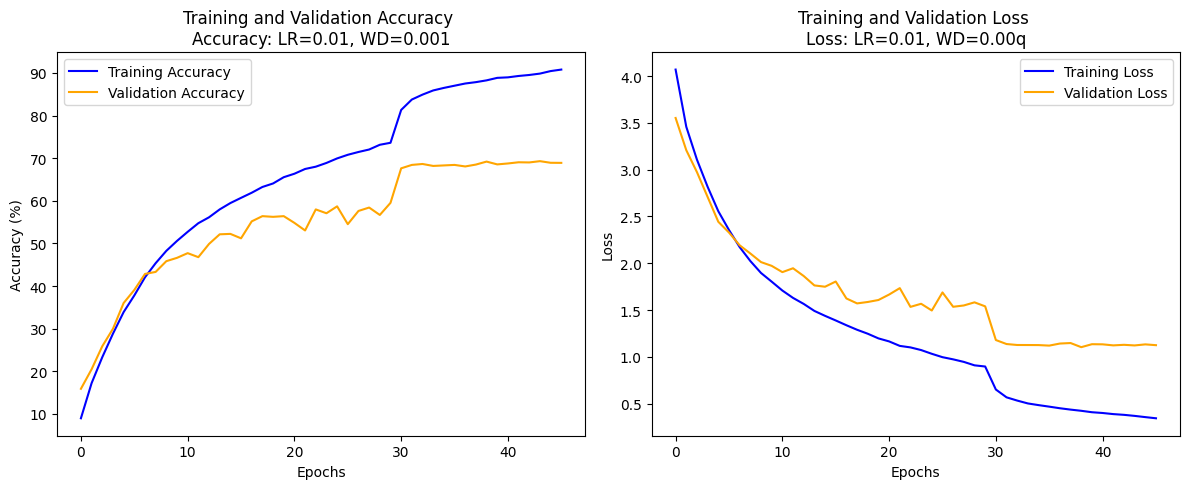

In [25]:
import matplotlib.pyplot as plt

# Using the data from your best run (LR=0.001, WD=0.0005)
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(best_history['training_acc'], label='Training Accuracy', color='blue')
plt.plot(best_history['validation_acc'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy \nAccuracy: LR=0.01, WD=0.001')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(best_history['training_loss'], label='Training Loss', color='blue')
plt.plot(best_history['validation_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss \nLoss: LR=0.01, WD=0.001')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()